# 01 — Keşifsel Veri Analizi (EDA)
**Veri Seti:** Store Item Demand Forecasting Challenge  
**Kapsam:** 10 mağaza × 50 ürün × 5 yıl günlük satış (2013–2017)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')

DATA_PATH = '../data/raw/train.csv'

## 1. Veri Yükleme ve Genel Bakış

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['date'])

print('=== BOYUT ===')
print(f'  Satır sayısı : {df.shape[0]:,}')
print(f'  Sütun sayısı : {df.shape[1]}')
print()
print('=== SÜTUNLAR ===')
print(df.dtypes.to_string())
print()
print('=== İLK 5 SATIR ===')
df.head()

=== BOYUT ===
  Satır sayısı : 913,000
  Sütun sayısı : 4

=== SÜTUNLAR ===
date     datetime64[ns]
store             int64
item              int64
sales             int64

=== İLK 5 SATIR ===


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
print('=== TEMEL İSTATİSTİKLER ===')
df.describe().round(2)

=== TEMEL İSTATİSTİKLER ===


,date,store,item,sales
count,913000,913000.00,913000.00,913000.00
mean,2015-07-02 11:59:59.999999744,5.50,25.50,52.25
min,2013-01-01 00:00:00,1.00,1.00,0.00
25%,2014-04-02 00:00:00,3.00,13.00,30.00
50%,2015-07-02 12:00:00,5.50,25.50,47.00
75%,2016-10-01 00:00:00,8.00,38.00,70.00
max,2017-12-31 00:00:00,10.00,50.00,231.00
std,NaN,2.87,14.43,28.80


In [4]:
print('=== KAPSAMLı BİLGİ ===')
print(f'  Tarih aralığı : {df["date"].min().date()}  →  {df["date"].max().date()}')
print(f'  Toplam gün    : {df["date"].nunique():,}')
print(f'  Mağaza sayısı : {df["store"].nunique()}')
print(f'  Ürün sayısı   : {df["item"].nunique()}')
print(f'  Toplam satış  : {df["sales"].sum():,}')
print(f'  Ort. günlük satış : {df["sales"].mean():.2f}')

=== KAPSAMLı BİLGİ ===
  Tarih aralığı : 2013-01-01  →  2017-12-31
  Toplam gün    : 1,826
  Mağaza sayısı : 10
  Ürün sayısı   : 50
  Toplam satış  : 47,704,512
  Ort. günlük satış : 52.25


## 2. Eksik Değer Analizi

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Eksik Sayı': missing, 'Oran (%)': missing_pct})
print(missing_df.to_string())
print()

if missing.sum() == 0:
    print('Veri setinde eksik değer bulunmamaktadır.')
else:
    print(f'Toplam {missing.sum()} eksik değer tespit edildi.')

       Eksik Sayı  Oran (%)
date            0       0.0
store           0       0.0
item            0       0.0
sales           0       0.0

Veri setinde eksik değer bulunmamaktadır.


In [6]:
# Beklenen kayıt sayısı kontrolü (10 mağaza × 50 ürün × 1826 gün)
expected_days = (df['date'].max() - df['date'].min()).days + 1
expected_rows = 10 * 50 * expected_days
print(f'Beklenen satır sayısı : {expected_rows:,}')
print(f'Gerçek satır sayısı   : {len(df):,}')
print(f'Fark                  : {expected_rows - len(df):,}')

Beklenen satır sayısı : 913,000
Gerçek satır sayısı   : 913,000
Fark                  : 0


## 3. Satış Dağılımı

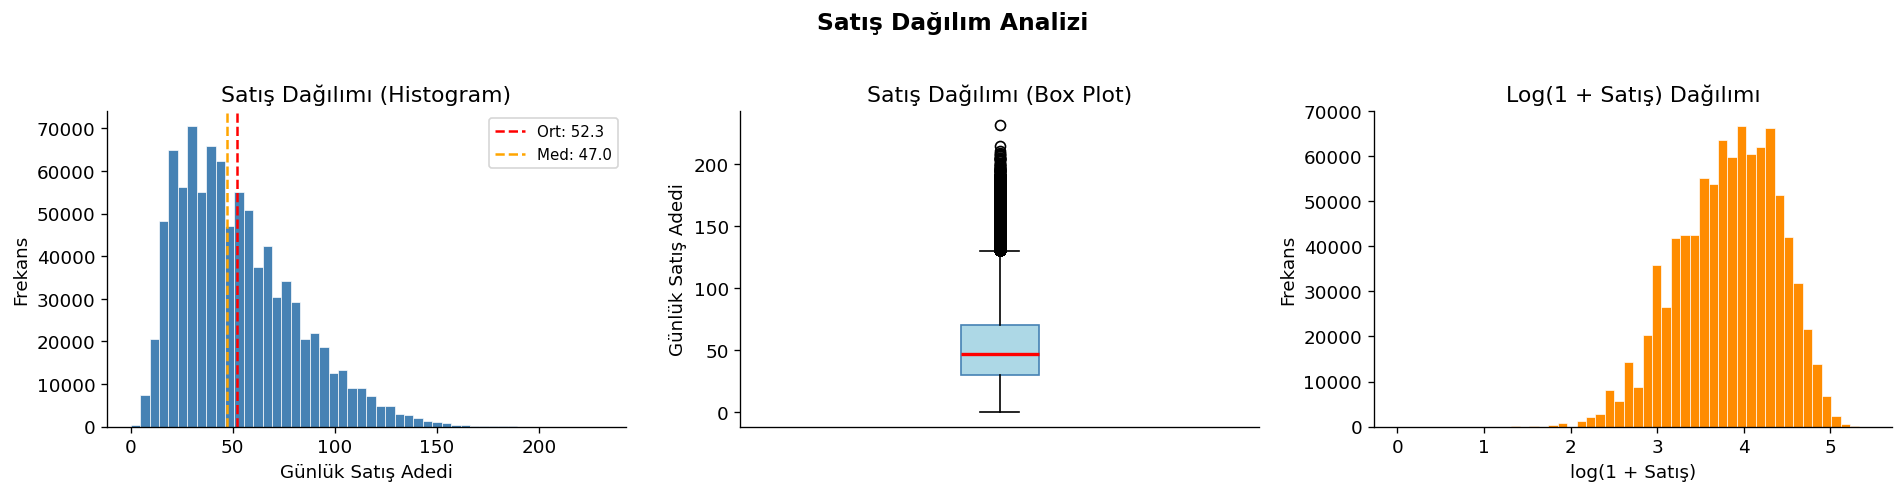

Çarpıklık (skewness) : 0.867
Basıklık (kurtosis)  : 0.509
Sıfır satış günleri  : 1


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(df['sales'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Satış Dağılımı (Histogram)')
axes[0].set_xlabel('Günlük Satış Adedi')
axes[0].set_ylabel('Frekans')
axes[0].axvline(df['sales'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Ort: {df["sales"].mean():.1f}')
axes[0].axvline(df['sales'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Med: {df["sales"].median():.1f}')
axes[0].legend(fontsize=9)

# Box plot
axes[1].boxplot(df['sales'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Satış Dağılımı (Box Plot)')
axes[1].set_ylabel('Günlük Satış Adedi')
axes[1].set_xticks([])

# Log dağılımı
log_sales = np.log1p(df['sales'])
axes[2].hist(log_sales, bins=50, color='darkorange', edgecolor='white', linewidth=0.4)
axes[2].set_title('Log(1 + Satış) Dağılımı')
axes[2].set_xlabel('log(1 + Satış)')
axes[2].set_ylabel('Frekans')

plt.suptitle('Satış Dağılım Analizi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Çarpıklık (skewness) : {df["sales"].skew():.3f}')
print(f'Basıklık (kurtosis)  : {df["sales"].kurtosis():.3f}')
print(f'Sıfır satış günleri  : {(df["sales"] == 0).sum():,}')

## 4. Zaman Serisi Trendi

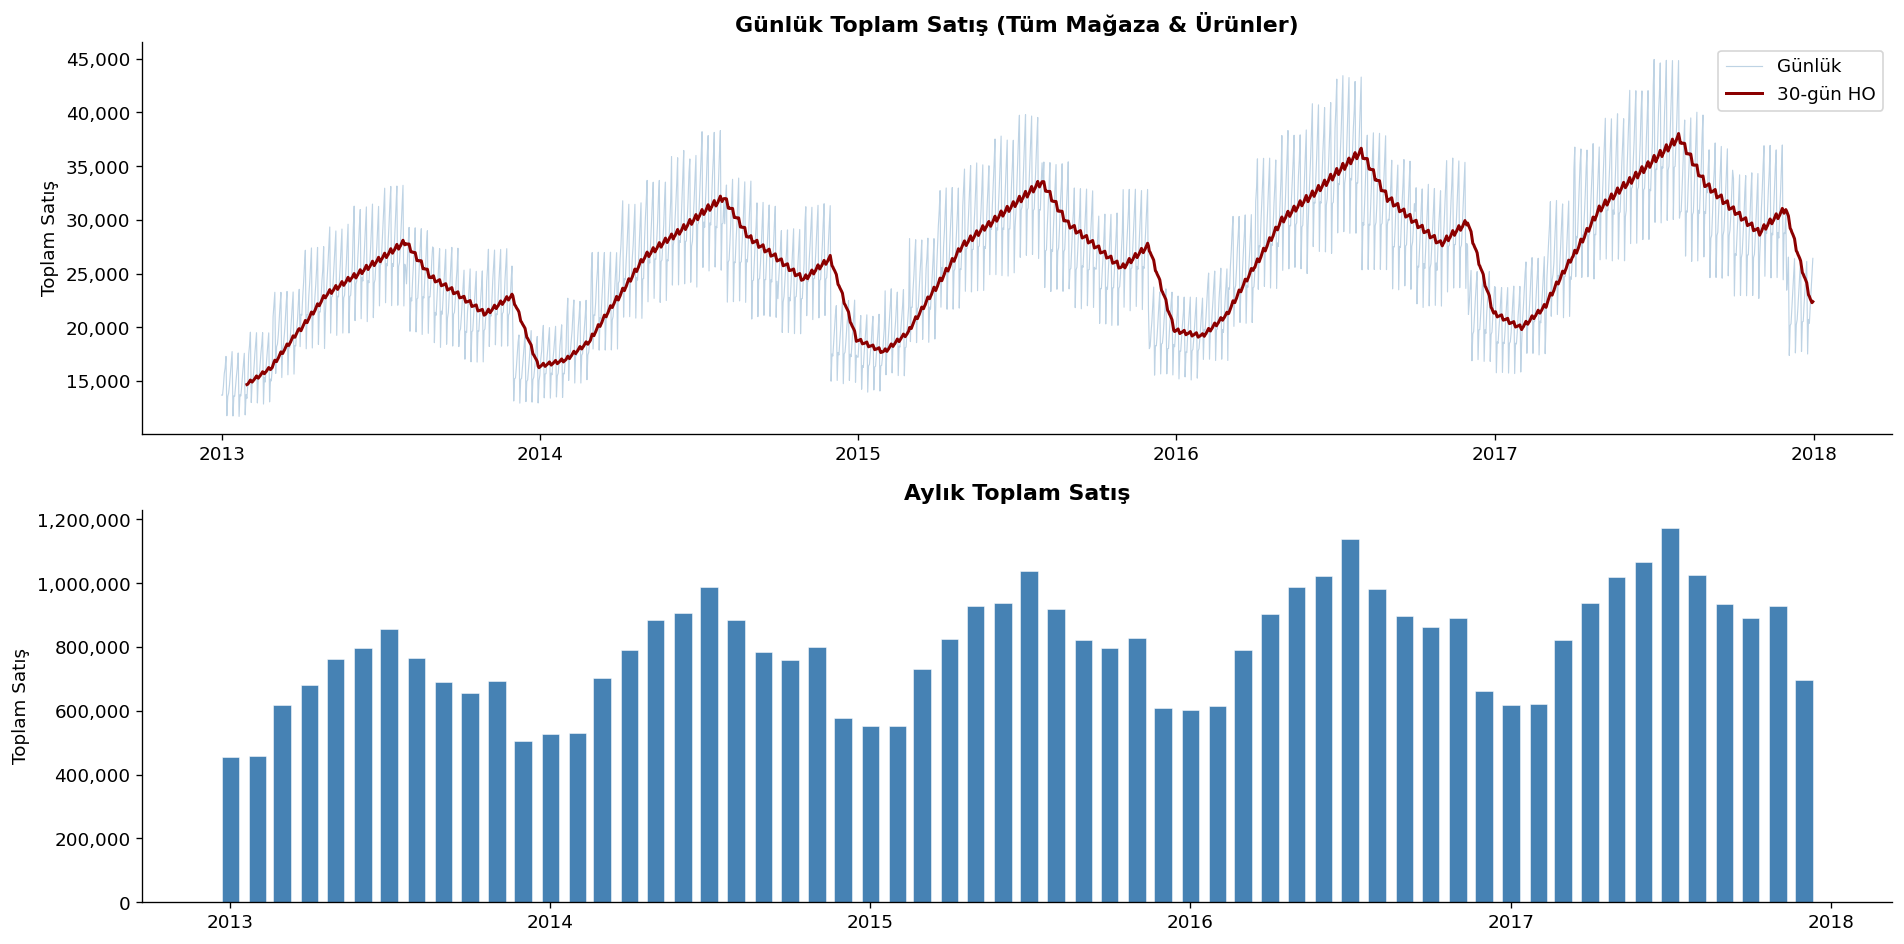

In [8]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['dow'] = df['date'].dt.dayofweek
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter

daily_sales = df.groupby('date')['sales'].sum().reset_index()
monthly_sales = df.groupby(df['date'].dt.to_period('M'))['sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Günlük toplam satış + 30 günlük hareketli ortalama
axes[0].plot(daily_sales['date'], daily_sales['sales'],
             alpha=0.35, color='steelblue', linewidth=0.7, label='Günlük')
rolling = daily_sales.set_index('date')['sales'].rolling(30).mean()
axes[0].plot(rolling.index, rolling.values,
             color='darkred', linewidth=1.8, label='30-gün HO')
axes[0].set_title('Günlük Toplam Satış (Tüm Mağaza & Ürünler)', fontweight='bold')
axes[0].set_ylabel('Toplam Satış')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Aylık toplam satış
axes[1].bar(monthly_sales.index, monthly_sales.values,
            width=20, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].set_title('Aylık Toplam Satış', fontweight='bold')
axes[1].set_ylabel('Toplam Satış')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

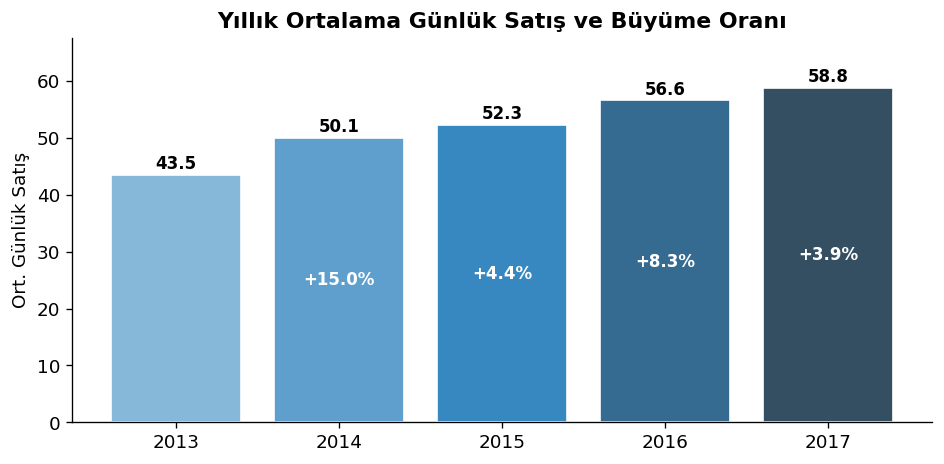

In [9]:
# Yıllık büyüme
yearly = df.groupby('year')['sales'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(yearly['year'].astype(str), yearly['sales'],
              color=sns.color_palette('Blues_d', len(yearly)), edgecolor='white')
for bar, val in zip(bars, yearly['sales']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

yoy = yearly['sales'].pct_change() * 100
for i, (yr, pct) in enumerate(zip(yearly['year'][1:], yoy[1:])):
    ax.text(i + 1, yearly['sales'].iloc[i + 1] / 2,
            f'+{pct:.1f}%', ha='center', va='center', color='white',
            fontsize=10, fontweight='bold')

ax.set_title('Yıllık Ortalama Günlük Satış ve Büyüme Oranı', fontweight='bold')
ax.set_ylabel('Ort. Günlük Satış')
ax.set_ylim(0, yearly['sales'].max() * 1.15)
plt.tight_layout()
plt.show()

## 5. Mevsimsellik Analizi

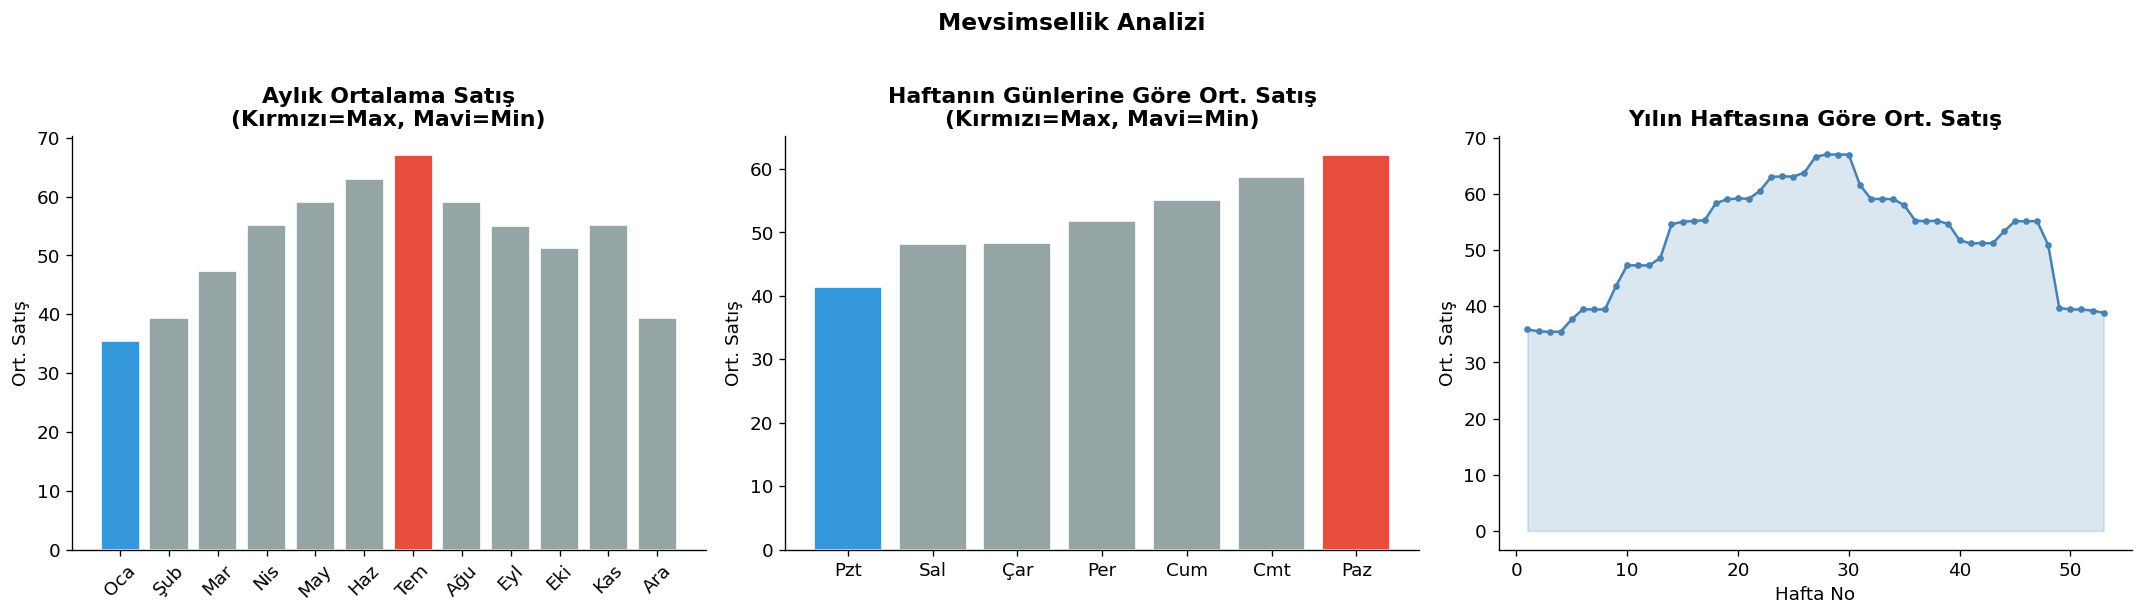

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Aylık mevsimsellik
monthly_avg = df.groupby('month')['sales'].mean()
month_names = ['Oca', 'Şub', 'Mar', 'Nis', 'May', 'Haz',
               'Tem', 'Ağu', 'Eyl', 'Eki', 'Kas', 'Ara']
colors_m = ['#e74c3c' if v == monthly_avg.max() else
             '#3498db' if v == monthly_avg.min() else '#95a5a6'
             for v in monthly_avg]
axes[0].bar(month_names, monthly_avg.values, color=colors_m, edgecolor='white')
axes[0].set_title('Aylık Ortalama Satış\n(Kırmızı=Max, Mavi=Min)', fontweight='bold')
axes[0].set_ylabel('Ort. Satış')
axes[0].tick_params(axis='x', rotation=45)

# Haftalık mevsimsellik
dow_avg = df.groupby('dow')['sales'].mean()
dow_names = ['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz']
colors_d = ['#e74c3c' if v == dow_avg.max() else
             '#3498db' if v == dow_avg.min() else '#95a5a6'
             for v in dow_avg]
axes[1].bar(dow_names, dow_avg.values, color=colors_d, edgecolor='white')
axes[1].set_title('Haftanın Günlerine Göre Ort. Satış\n(Kırmızı=Max, Mavi=Min)', fontweight='bold')
axes[1].set_ylabel('Ort. Satış')

# Haftalık mevsimsellik (çizgi)
weekly_avg = df.groupby('week')['sales'].mean()
axes[2].plot(weekly_avg.index, weekly_avg.values,
             color='steelblue', linewidth=1.5, marker='o', markersize=3)
axes[2].fill_between(weekly_avg.index, weekly_avg.values,
                     alpha=0.2, color='steelblue')
axes[2].set_title('Yılın Haftasına Göre Ort. Satış', fontweight='bold')
axes[2].set_xlabel('Hafta No')
axes[2].set_ylabel('Ort. Satış')

plt.suptitle('Mevsimsellik Analizi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

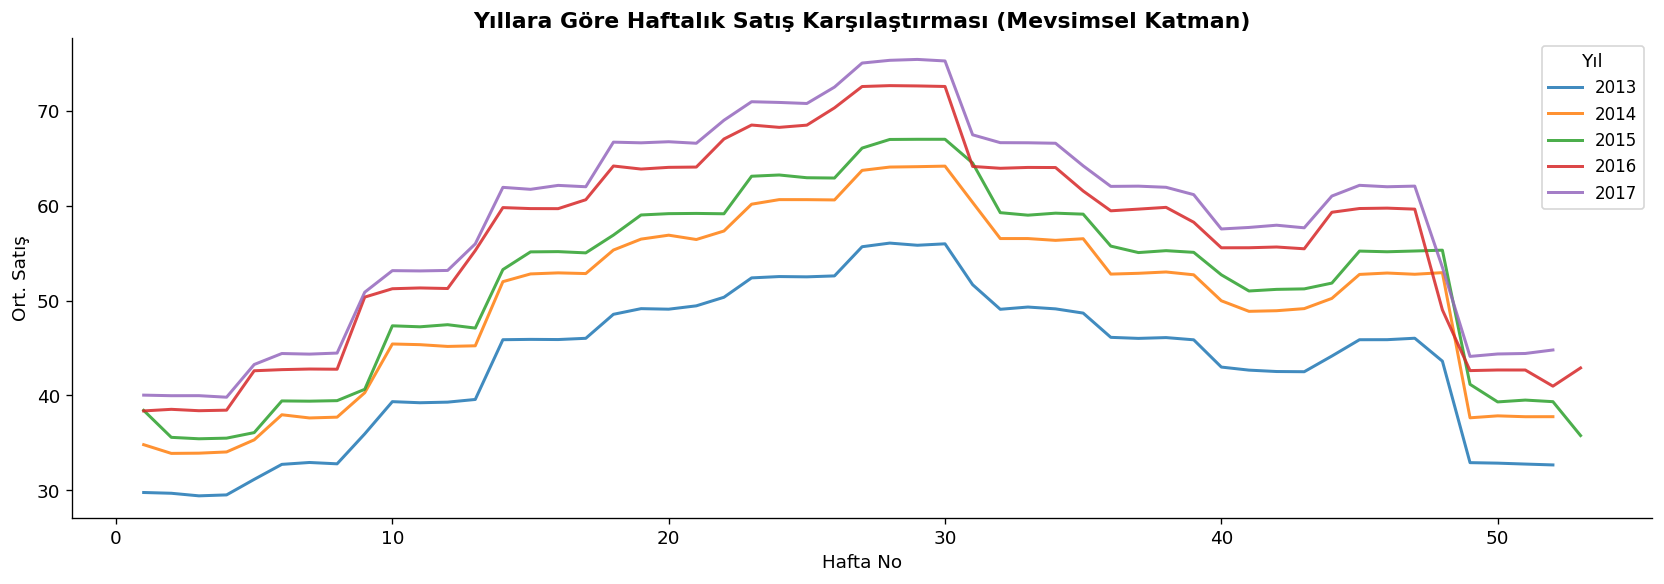

In [11]:
# Çizgi grafik: yıllar üst üste (mevsimsel karşılaştırma)
fig, ax = plt.subplots(figsize=(14, 5))

colors_yr = sns.color_palette('tab10', 5)
for i, year in enumerate(sorted(df['year'].unique())):
    yr_data = df[df['year'] == year].groupby('week')['sales'].mean()
    ax.plot(yr_data.index, yr_data.values,
            label=str(year), color=colors_yr[i], linewidth=1.8, alpha=0.85)

ax.set_title('Yıllara Göre Haftalık Satış Karşılaştırması (Mevsimsel Katman)', fontweight='bold')
ax.set_xlabel('Hafta No')
ax.set_ylabel('Ort. Satış')
ax.legend(title='Yıl', fontsize=10)
plt.tight_layout()
plt.show()

## 6. Klasik Zaman Serisi Ayrıştırma (STL)

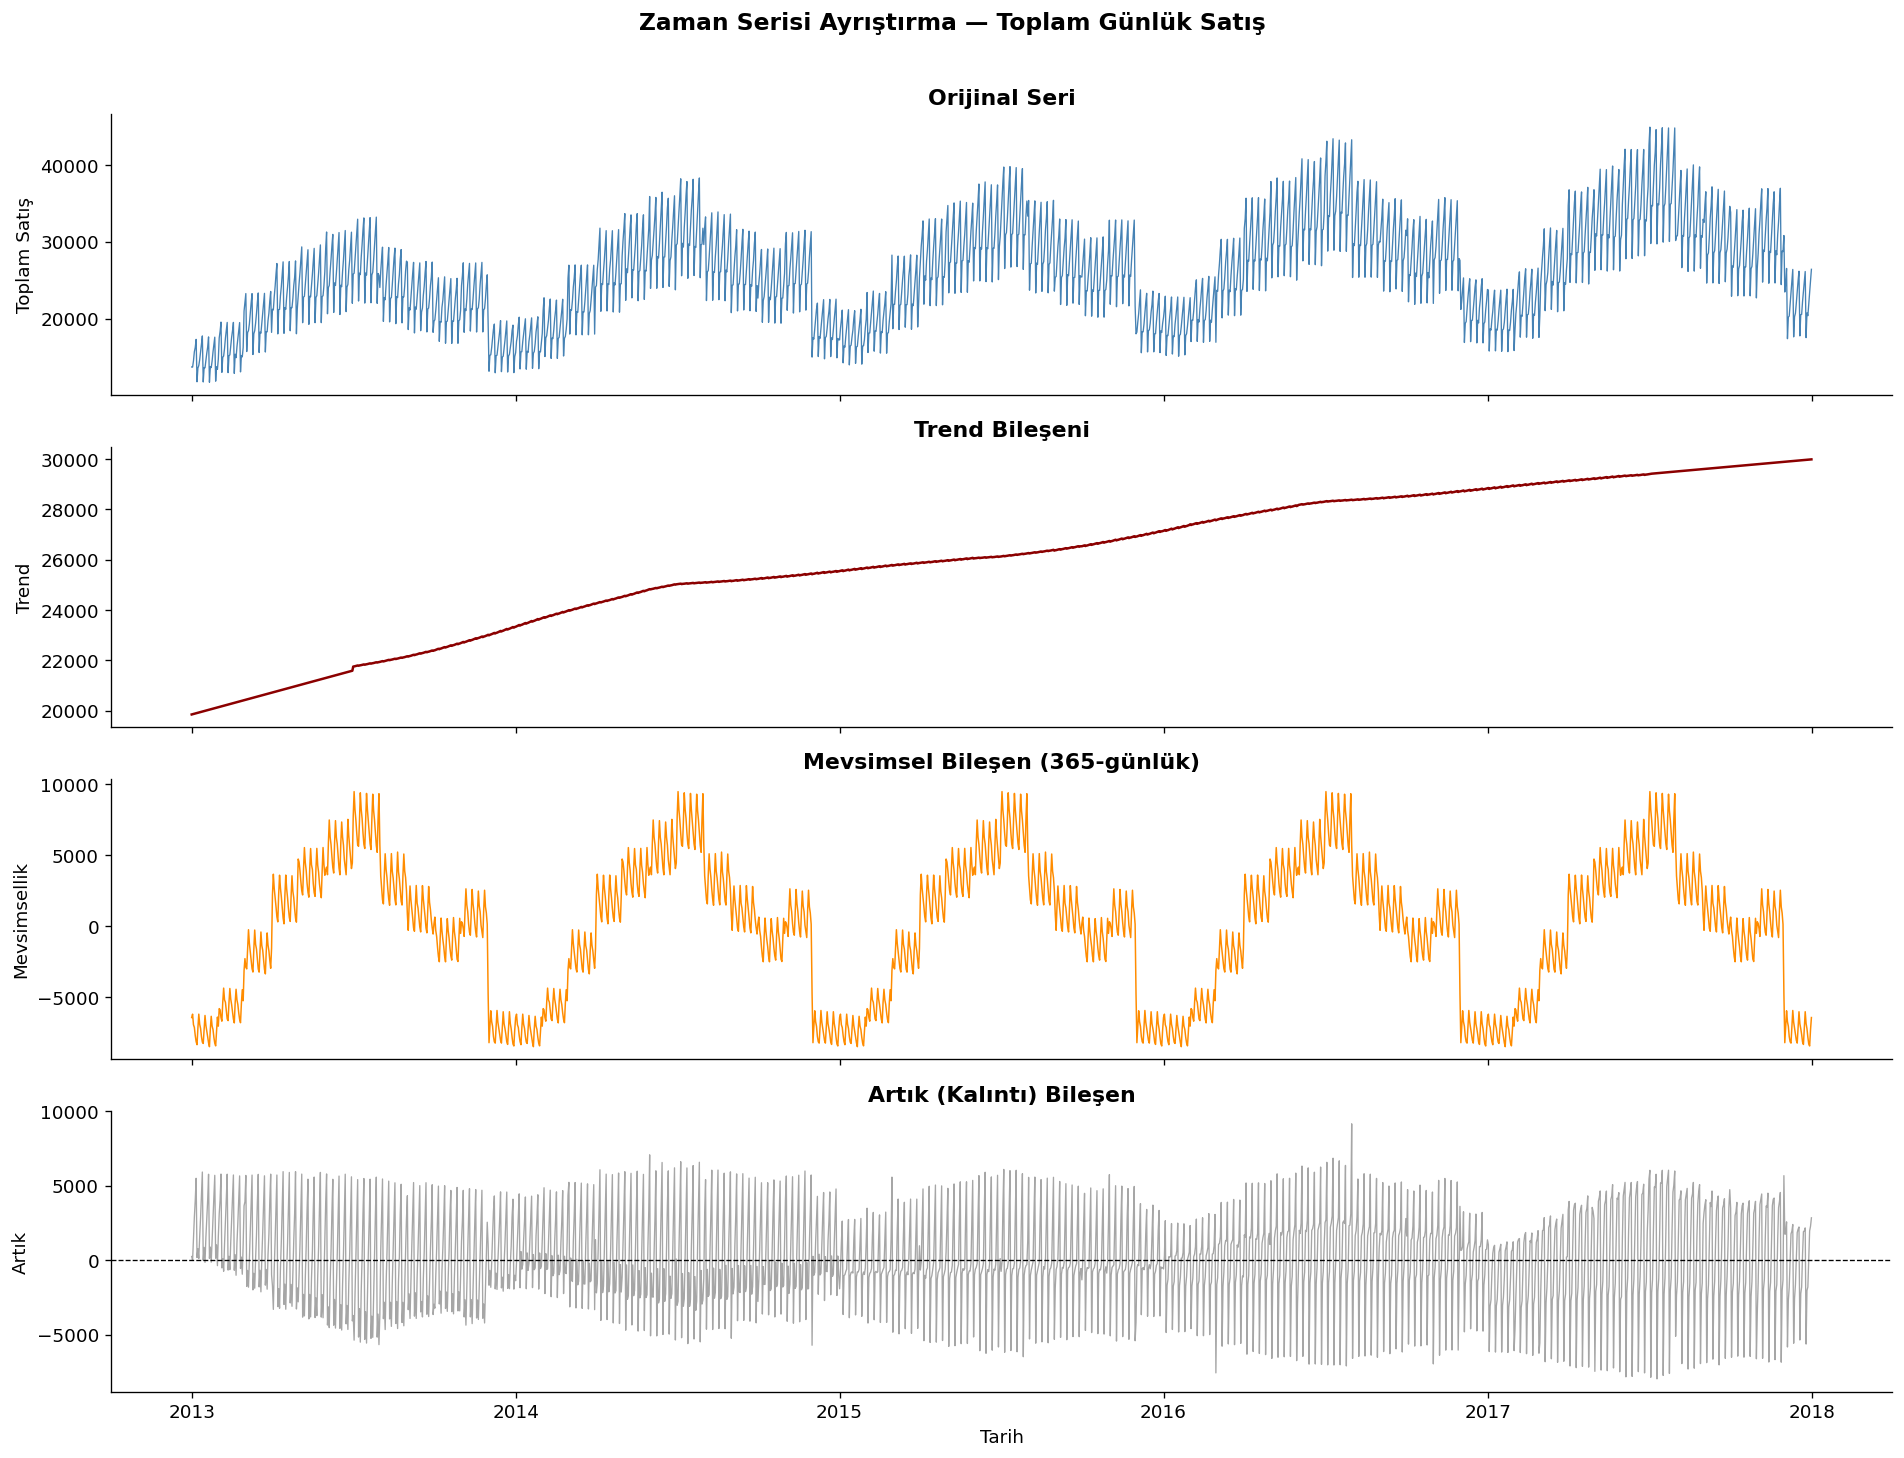

In [12]:
# Tüm mağaza/ürün toplamı, aylık — en temiz sinyal
ts = df.groupby('date')['sales'].sum()

decomp = seasonal_decompose(ts, model='additive', period=365, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].plot(ts.index, ts.values, color='steelblue', linewidth=0.8)
axes[0].set_title('Orijinal Seri', fontweight='bold')
axes[0].set_ylabel('Toplam Satış')

axes[1].plot(decomp.trend.index, decomp.trend.values, color='darkred', linewidth=1.5)
axes[1].set_title('Trend Bileşeni', fontweight='bold')
axes[1].set_ylabel('Trend')

axes[2].plot(decomp.seasonal.index, decomp.seasonal.values, color='darkorange', linewidth=0.9)
axes[2].set_title('Mevsimsel Bileşen (365-günlük)', fontweight='bold')
axes[2].set_ylabel('Mevsimsellik')

axes[3].plot(decomp.resid.index, decomp.resid.values, color='gray', linewidth=0.8, alpha=0.7)
axes[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[3].set_title('Artık (Kalıntı) Bileşen', fontweight='bold')
axes[3].set_ylabel('Artık')
axes[3].set_xlabel('Tarih')

plt.suptitle('Zaman Serisi Ayrıştırma — Toplam Günlük Satış',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Mağaza ve Ürün Bazlı Analiz

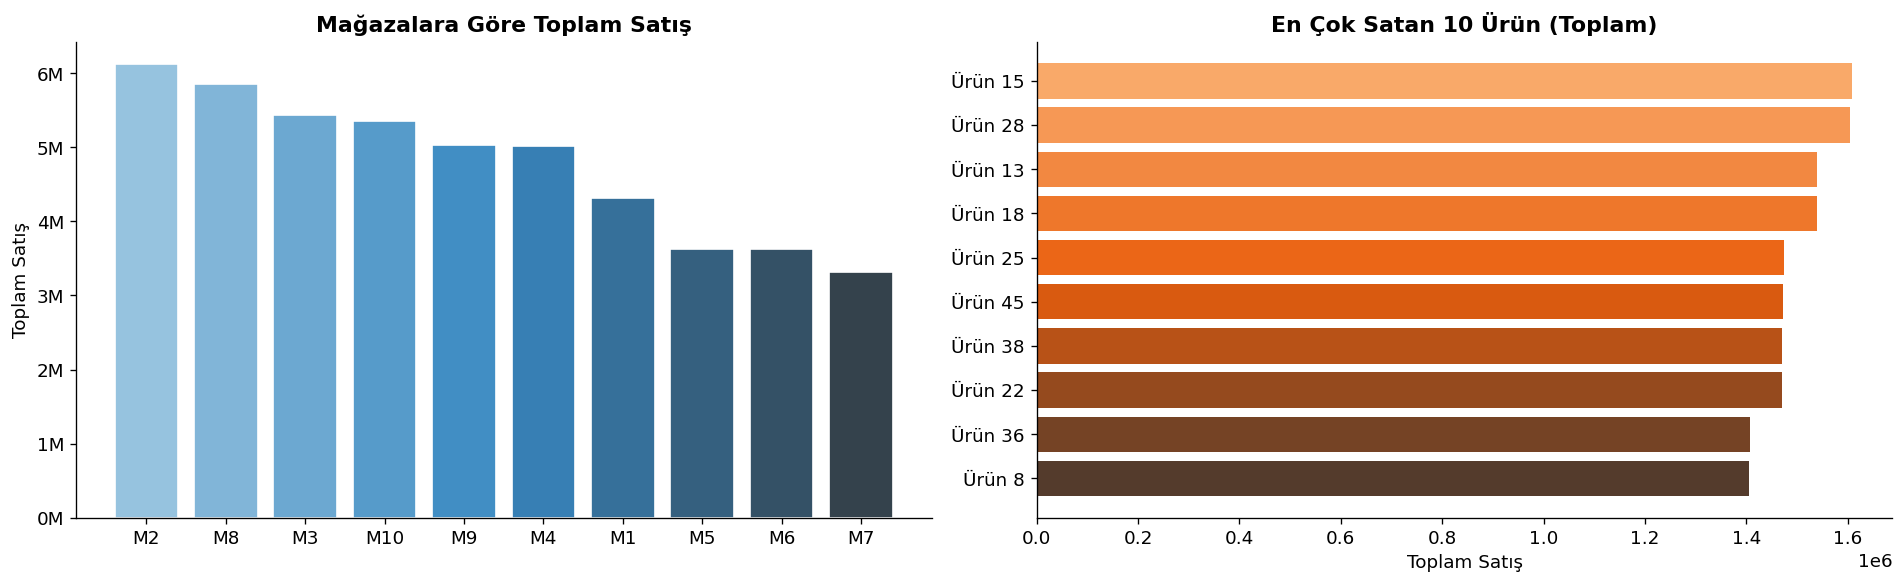

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mağaza bazlı toplam satış
store_sales = df.groupby('store')['sales'].sum().sort_values(ascending=False)
axes[0].bar([f'M{s}' for s in store_sales.index], store_sales.values,
            color=sns.color_palette('Blues_d', len(store_sales)), edgecolor='white')
axes[0].set_title('Mağazalara Göre Toplam Satış', fontweight='bold')
axes[0].set_ylabel('Toplam Satış')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))

# En çok satan 10 ürün
item_sales = df.groupby('item')['sales'].sum().sort_values(ascending=False).head(10)
axes[1].barh([f'Ürün {i}' for i in item_sales.index],
             item_sales.values,
             color=sns.color_palette('Oranges_d', len(item_sales)))
axes[1].set_title('En Çok Satan 10 Ürün (Toplam)', fontweight='bold')
axes[1].set_xlabel('Toplam Satış')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

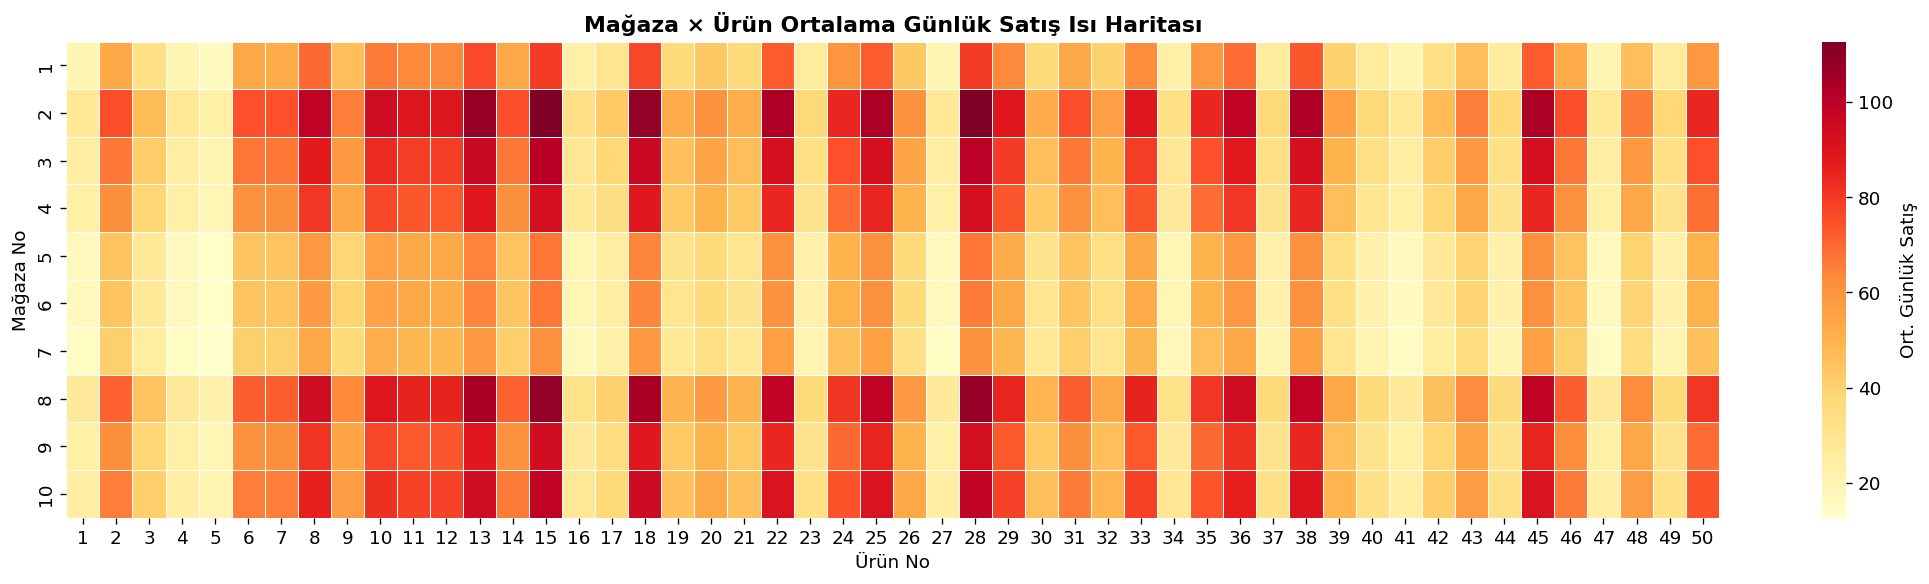

In [14]:
# Isı haritası: Mağaza × Ürün ortalama satış
pivot = df.pivot_table(values='sales', index='store', columns='item', aggfunc='mean')

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', fmt='.0f',
            linewidths=0.3, cbar_kws={'label': 'Ort. Günlük Satış'})
ax.set_title('Mağaza × Ürün Ortalama Günlük Satış Isı Haritası', fontweight='bold')
ax.set_xlabel('Ürün No')
ax.set_ylabel('Mağaza No')
plt.tight_layout()
plt.show()

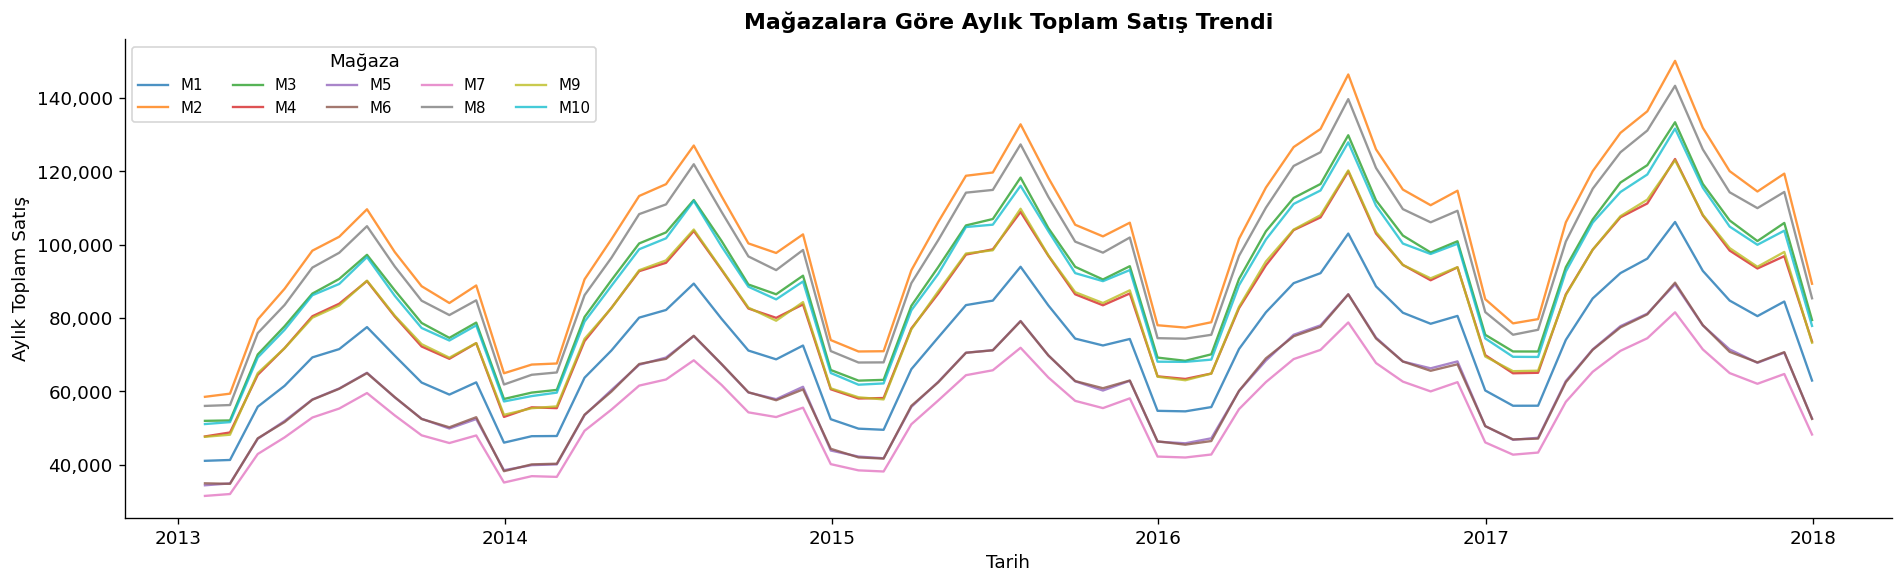

In [15]:
# Mağaza bazlı aylık satış trendi
store_monthly = (df.groupby(['store', pd.Grouper(key='date', freq='ME')])['sales']
                   .sum().reset_index())

fig, ax = plt.subplots(figsize=(16, 5))
for store_id in sorted(df['store'].unique()):
    d = store_monthly[store_monthly['store'] == store_id]
    ax.plot(d['date'], d['sales'], label=f'M{store_id}', linewidth=1.4, alpha=0.8)

ax.set_title('Mağazalara Göre Aylık Toplam Satış Trendi', fontweight='bold')
ax.set_ylabel('Aylık Toplam Satış')
ax.set_xlabel('Tarih')
ax.legend(title='Mağaza', ncol=5, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 8. Korelasyon ve Otokorelasyon

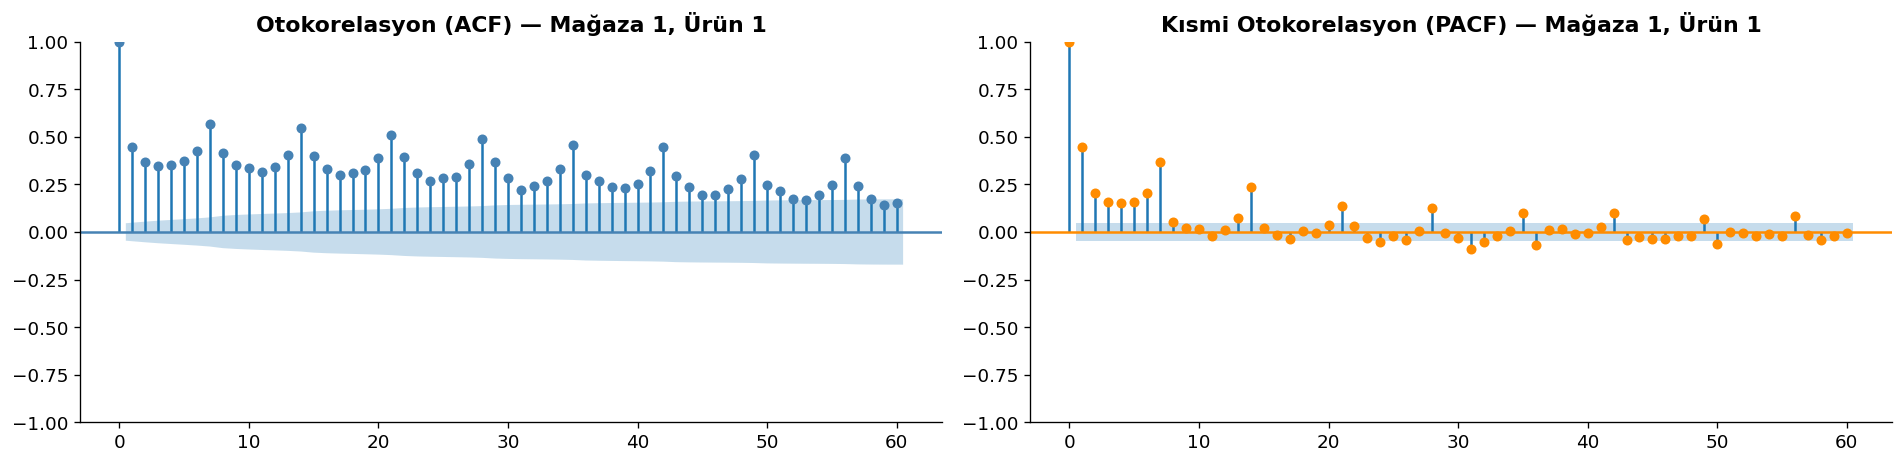

ACF analizi: 7 ve 14. gecikmeler belirgin → güçlü haftalık mevsimsellik


In [16]:
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Tek bir mağaza-ürün çifti için ACF/PACF (gürültü azaltmak için)
ts_single = df[(df['store'] == 1) & (df['item'] == 1)].set_index('date')['sales']

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(ts_single, lags=60, ax=axes[0], color='steelblue')
axes[0].set_title('Otokorelasyon (ACF) — Mağaza 1, Ürün 1', fontweight='bold')

plot_pacf(ts_single, lags=60, ax=axes[1], color='darkorange', method='ywm')
axes[1].set_title('Kısmi Otokorelasyon (PACF) — Mağaza 1, Ürün 1', fontweight='bold')

plt.tight_layout()
plt.show()

print('ACF analizi: 7 ve 14. gecikmeler belirgin → güçlü haftalık mevsimsellik')

## 9. EDA Özeti ve Bulgular

In [17]:
print('=' * 60)
print('EDA ÖZET BULGULARI')
print('=' * 60)
print()
print('VERİ KALİTESİ')
print(f'  • {len(df):,} satır, {df.shape[1]} sütun')
print(f'  • Eksik değer: YOK')
print(f'  • Tarih aralığı: 2013-01-01 → 2017-12-31 (5 yıl)')
print()
print('TREND')
yoy_growth = (df[df['year']==2017]['sales'].mean() /
              df[df['year']==2013]['sales'].mean() - 1) * 100
print(f'  • 5 yılda toplam satış artışı: %{yoy_growth:.1f}')
print(f'  • Yıllık ortalama büyüme: ~%{yoy_growth/4:.1f}')
print()
print('MEVSİMSELLİK')
peak_month = df.groupby('month')['sales'].mean().idxmax()
low_month = df.groupby('month')['sales'].mean().idxmin()
print(f'  • En yüksek satış ayı: {month_names[peak_month-1]} (Ay {peak_month})')
print(f'  • En düşük satış ayı : {month_names[low_month-1]} (Ay {low_month})')
print(f'  • Hafta sonu etkisi  : Pazar > Cumartesi > Hafta içi')
print()
print('MAĞAZA / ÜRÜN')
print(f'  • 10 mağaza, 50 ürün → 500 benzersiz seri')
print(f'  • Mağazalar arası satış farkı görece küçük (dengeli)')
print(f'  • Ürünler arası fark belirgin (uzun kuyruk dağılımı)')
print()
print('MODEL ÖNERİLERİ')
print('  • Güçlü trend + yıllık mevsimsellik → Prophet, SARIMA uygun')
print('  • Haftalık döngü (lag=7)            → XGBoost/LightGBM + lag features')
print('  • Hiyerarşi (mağaza→ürün)           → Global model tercih edilmeli')

EDA ÖZET BULGULARI

VERİ KALİTESİ
  • 913,000 satır, 9 sütun
  • Eksik değer: YOK
  • Tarih aralığı: 2013-01-01 → 2017-12-31 (5 yıl)

TREND
  • 5 yılda toplam satış artışı: %35.2
  • Yıllık ortalama büyüme: ~%8.8

MEVSİMSELLİK
  • En yüksek satış ayı: Tem (Ay 7)
  • En düşük satış ayı : Oca (Ay 1)
  • Hafta sonu etkisi  : Pazar > Cumartesi > Hafta içi

MAĞAZA / ÜRÜN
  • 10 mağaza, 50 ürün → 500 benzersiz seri
  • Mağazalar arası satış farkı görece küçük (dengeli)
  • Ürünler arası fark belirgin (uzun kuyruk dağılımı)

MODEL ÖNERİLERİ
  • Güçlü trend + yıllık mevsimsellik → Prophet, SARIMA uygun
  • Haftalık döngü (lag=7)            → XGBoost/LightGBM + lag features
  • Hiyerarşi (mağaza→ürün)           → Global model tercih edilmeli
